In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl
import warnings; warnings.simplefilter('ignore')
import os
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [32]:
data          = np.load("../../data/sims/BolshoiP_500_shmf.npz")
host_id       = data["host_id"]
logMvir       = data["logMvir"]
log10Mvir_sub = data["log10Mvir_sub"]   # shape (n_host, n_sub_max), NaN-padded

In [58]:
DF1 = jsm_ancillary.load_shmf_z0("../../data/zhao/DF_test/DF_1/")

split_DF1 = jsm_ancillary.split_mass_spec(DF1)

In [59]:
binz = np.logspace(np.log10(7.75e10), 14, 20)
bin_edges = (binz[:-1] + binz[1:]) / 2
splitMvir = np.linspace(12.6, 14.0, 8)
mvir_label = np.array([12.6, 12.8, 13.0, 13.2, 13.4, 13.6, 13.8, 14.0])
xvals = np.log10(bin_edges)

In [62]:

def compute_average_SHMF_regimes(df):
    surv_masses = jsm_ancillary.stack_ragged_series(df, "shmf_surviving_all")
    rvir_masses = jsm_ancillary.stack_ragged_series(df, "shmf_rvir_surv_all")
    art_masses = jsm_ancillary.stack_ragged_series(df, "shmf_artificial_all")

    surv_hist = np.apply_along_axis(jsm_stats.count_straight, 1, surv_masses, mass_bins=binz)
    rvir_hist = np.apply_along_axis(jsm_stats.count_straight, 1, rvir_masses, mass_bins=binz)
    art_hist = np.apply_along_axis(jsm_stats.count_straight, 1, art_masses, mass_bins=binz)

    surv_shmf = np.average(surv_hist, axis=0)
    rvir_shmf = np.average(rvir_hist, axis=0)
    art_shmf = np.average(art_hist, axis=0)

    surv_shmf_std = np.std(surv_hist, axis=0)
    rvir_shmf_std = np.std(rvir_hist, axis=0)
    art_shmf_std = np.std(art_hist, axis=0)

    return np.array([surv_shmf, rvir_shmf, art_shmf]), np.array([surv_shmf_std, rvir_shmf_std, art_shmf_std])

def count_bol(vals):
    bolhist = np.apply_along_axis(jsm_stats.count_straight, 1, vals, mass_bins=binz)
    return np.average(bolhist, axis=0)

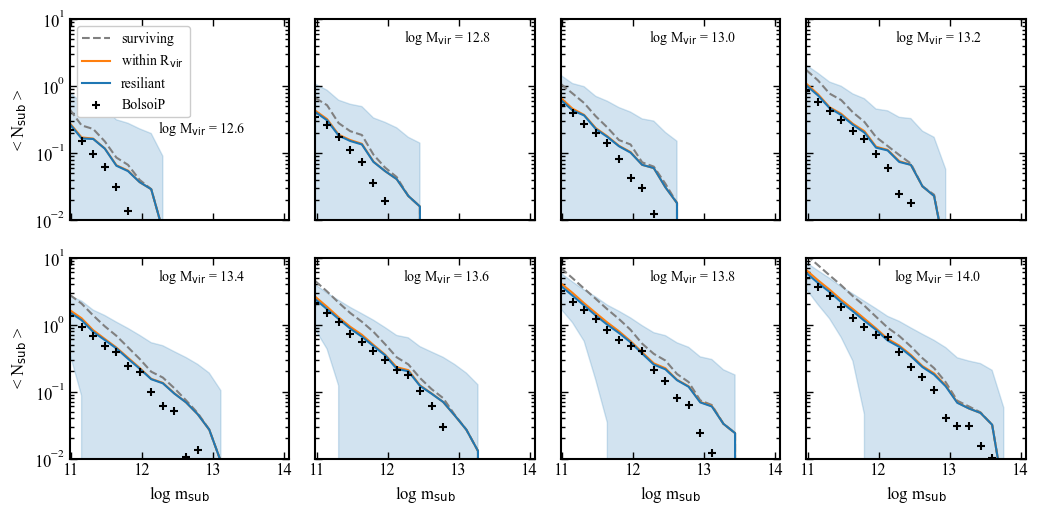

In [63]:
fig, axes = plt.subplots(2, 4, sharex=True, sharey=True,
                              figsize=(double_textwidth*1.5, single_textwidth*1.5))

axes = axes.flatten()

for i in range(8):
    
    ax = axes[i]

    counts_i, stds_i = compute_average_SHMF_regimes(split_DF1[i])
    ax.fill_between(xvals, counts_i[2]-stds_i[2], counts_i[2]+stds_i[2], color="C0", alpha=0.2)

    ax.plot(xvals, counts_i[0], color="grey", ls="--", label="surviving")
    ax.plot(xvals, counts_i[1], color="C1", label="within R$_{\\rm vir}$")
    ax.plot(xvals, counts_i[2], color="C0", label="resiliant")

    mass_cut_i = (splitMvir[i]-0.1 < logMvir) & (logMvir < splitMvir[i]+0.1)
    bolcounts = count_bol(10**log10Mvir_sub[mass_cut_i])
    ax.scatter(xvals, bolcounts, marker="+", c="k", label="BolsoiP", zorder=10)
    
    if i==0:
        ax.text(0.6, 0.5, f"log M$_{{\\rm vir}}$ = {mvir_label[i]:.1f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=10)
    else:
        ax.text(0.6, 0.95, f"log M$_{{\\rm vir}}$ = {mvir_label[i]:.1f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=10)

axes[0].set_xticks([11, 12, 13, 14])
axes[0].set_xlim(xvals.min())
axes[0].set_ylim(1e-2, 10)
axes[0].set_yscale("log")

for ax in axes[-4:]:
    ax.set_xlabel("log m$_{\\rm sub}$")
for ax in axes[::4]:
    ax.set_ylabel("< N$_{\\rm sub}$ >")

axes[0].legend(framealpha=1, loc=2, fontsize=10)

plt.tight_layout()
# plt.savefig("../../figures/SHMF_all.pdf", bbox_inches="tight")
plt.show()


In [64]:
DF3 = jsm_ancillary.load_shmf_z0("../../data/zhao/DF_test/DF_3/")

split_DF3 = jsm_ancillary.split_mass_spec(DF3)

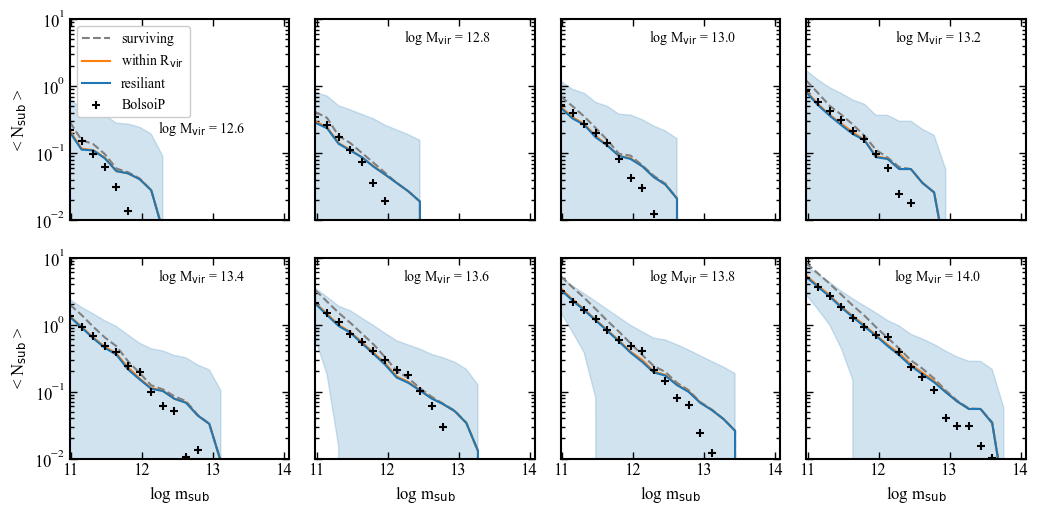

In [66]:
fig, axes = plt.subplots(2, 4, sharex=True, sharey=True,
                              figsize=(double_textwidth*1.5, single_textwidth*1.5))

axes = axes.flatten()

for i in range(8):
    
    ax = axes[i]

    counts_i, stds_i = compute_average_SHMF_regimes(split_DF3[i])
    ax.fill_between(xvals, counts_i[2]-stds_i[2], counts_i[2]+stds_i[2], color="C0", alpha=0.2)

    ax.plot(xvals, counts_i[0], color="grey", ls="--", label="surviving")
    ax.plot(xvals, counts_i[1], color="C1", label="within R$_{\\rm vir}$")
    ax.plot(xvals, counts_i[2], color="C0", label="resiliant")

    mass_cut_i = (splitMvir[i]-0.1 < logMvir) & (logMvir < splitMvir[i]+0.1)
    bolcounts = count_bol(10**log10Mvir_sub[mass_cut_i])
    ax.scatter(xvals, bolcounts, marker="+", c="k", label="BolsoiP", zorder=10)
    
    if i==0:
        ax.text(0.6, 0.5, f"log M$_{{\\rm vir}}$ = {mvir_label[i]:.1f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=10)
    else:
        ax.text(0.6, 0.95, f"log M$_{{\\rm vir}}$ = {mvir_label[i]:.1f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=10)

axes[0].set_xticks([11, 12, 13, 14])
axes[0].set_xlim(xvals.min())
axes[0].set_ylim(1e-2, 10)
axes[0].set_yscale("log")

for ax in axes[-4:]:
    ax.set_xlabel("log m$_{\\rm sub}$")
for ax in axes[::4]:
    ax.set_ylabel("< N$_{\\rm sub}$ >")

axes[0].legend(framealpha=1, loc=2, fontsize=10)

plt.tight_layout()
# plt.savefig("../../figures/SHMF_all.pdf", bbox_inches="tight")
plt.show()


In [71]:
DF10 = jsm_ancillary.load_shmf_z0("../../data/zhao/DF_test/DF_10/")

split_DF10 = jsm_ancillary.split_mass_spec(DF10)

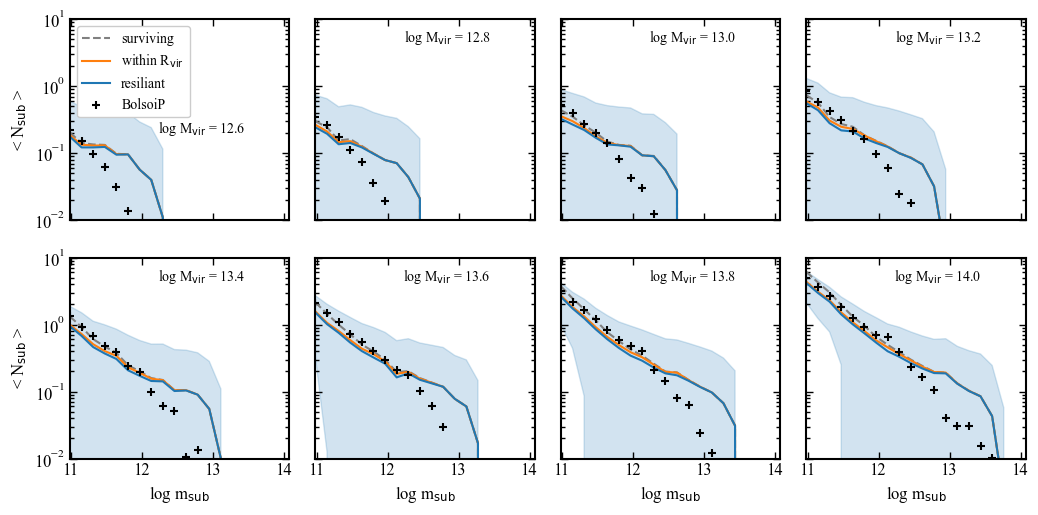

In [72]:
fig, axes = plt.subplots(2, 4, sharex=True, sharey=True,
                              figsize=(double_textwidth*1.5, single_textwidth*1.5))

axes = axes.flatten()

for i in range(8):
    
    ax = axes[i]

    counts_i, stds_i = compute_average_SHMF_regimes(split_DF10[i])
    ax.fill_between(xvals, counts_i[2]-stds_i[2], counts_i[2]+stds_i[2], color="C0", alpha=0.2)

    ax.plot(xvals, counts_i[0], color="grey", ls="--", label="surviving")
    ax.plot(xvals, counts_i[1], color="C1", label="within R$_{\\rm vir}$")
    ax.plot(xvals, counts_i[2], color="C0", label="resiliant")

    mass_cut_i = (splitMvir[i]-0.1 < logMvir) & (logMvir < splitMvir[i]+0.1)
    bolcounts = count_bol(10**log10Mvir_sub[mass_cut_i])
    ax.scatter(xvals, bolcounts, marker="+", c="k", label="BolsoiP", zorder=10)
    
    if i==0:
        ax.text(0.6, 0.5, f"log M$_{{\\rm vir}}$ = {mvir_label[i]:.1f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=10)
    else:
        ax.text(0.6, 0.95, f"log M$_{{\\rm vir}}$ = {mvir_label[i]:.1f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=10)

axes[0].set_xticks([11, 12, 13, 14])
axes[0].set_xlim(xvals.min())
axes[0].set_ylim(1e-2, 10)
axes[0].set_yscale("log")

for ax in axes[-4:]:
    ax.set_xlabel("log m$_{\\rm sub}$")
for ax in axes[::4]:
    ax.set_ylabel("< N$_{\\rm sub}$ >")

axes[0].legend(framealpha=1, loc=2, fontsize=10)

plt.tight_layout()
# plt.savefig("../../figures/SHMF_all.pdf", bbox_inches="tight")
plt.show()


In [ ]:
def compute_average_SHMF_orders(df):
    all_masses = jsm_ancillary.stack_ragged_series(df, "shmf_artificial_all")
    k1_masses = jsm_ancillary.stack_ragged_series(df, "shmf_artificial_k1")
    k2_masses = jsm_ancillary.stack_ragged_series(df, "shmf_artificial_k2")
    k3_masses = jsm_ancillary.stack_ragged_series(df, "shmf_artificial_k3")

    all_hist = np.apply_along_axis(jsm_stats.count_straight, 1, all_masses, mass_bins=binz)
    k1_hist = np.apply_along_axis(jsm_stats.count_straight, 1, k1_masses, mass_bins=binz)
    k2_hist = np.apply_along_axis(jsm_stats.count_straight, 1, k2_masses, mass_bins=binz)
    k3_hist = np.apply_along_axis(jsm_stats.count_straight, 1, k3_masses, mass_bins=binz)

    all_shmf = np.average(all_hist, axis=0)
    k1_shmf = np.average(k1_hist, axis=0)
    k2_shmf = np.average(k2_hist, axis=0)
    k3_shmf = np.average(k3_hist, axis=0)

    return np.array([all_shmf, k1_shmf, k2_shmf, k3_shmf])

In [ ]:
fig, axes = plt.subplots(2, 4, sharex=True, sharey=True,
                              figsize=(double_textwidth, single_textwidth*1.1))

axes = axes.flatten()

for i in range(8):
    
    ax = axes[i]
    ax.set_yscale("log")
    ax.set_xscale("log")

    counts_i = compute_average_SHMF_orders(split[i])
    ax.plot(bin_edges, counts_i[0], color="k", label="all")
    ax.plot(bin_edges, counts_i[1], color="C0", label="k=1", ls="--")
    ax.plot(bin_edges, counts_i[2], color="C1", label="k=2", ls="--")
    ax.plot(bin_edges, counts_i[3], color="C2", label="k=3+", ls="--")


    if i==0:
        ax.text(0.6, 0.4, f"log M$_{{\\rm vir}}$ = {mvir_label[i]:.1f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=10)
    else:
        ax.text(0.6, 0.95, f"log M$_{{\\rm vir}}$ = {mvir_label[i]:.1f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=10)

axes[0].set_xticks([11, 12, 13, 14])
axes[0].set_xlim(xvals.min())
axes[0].set_ylim(1e-2, 10)
axes[0].set_yscale("log")

for ax in axes[-4:]:
    ax.set_xlabel("m$_{\\rm sub}$")
for ax in axes[::4]:
    ax.set_ylabel("< N$_{\\rm sub}$ >")

axes[0].legend(framealpha=1, loc=4)

plt.tight_layout()
# plt.savefig("../../figures/paper/Nacc_orders.pdf", bbox_inches="tight")
plt.show()
